### Linear Regression


In [31]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### 1. Data Retrieval and Collection

In [6]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    return df  
df = load_data("Salary_data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [8]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


### 2. Data Cleaning

In [11]:
df.isnull().sum()

# if missing value exist:
df = df.dropna()

In [12]:
df.drop_duplicates()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [13]:
# Check types:

df.dtypes

YearsExperience    float64
Salary               int64
dtype: object

### 3. Feature Design

In [16]:
feature = df[['YearsExperience']]
target = df['Salary']
feature.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


### 4. Algorithm Selection

Linear Regression is appropriate because there is a continuous relationship between YearsExperience and Salary. We assume a linear relationship where salary increases proportionally with experience.


### 5. Loss Function Selection

We use Mean Squared Error (MSE), which measures the average squared difference between actual and predicted values.
MSE is used as a loss function for linear regression. It penalizes large errors more heavily. 
A lower MSE indicates that the model is making more accurate predictions and fitting the data better.

### 6. Model Learning (Training)

#### Train/Test Split

In [17]:
x_tr, x_te, y_tr, y_te = train_test_split(feature, target, test_size=0.5, random_state=42)
x_tr.shape, x_te.shape, y_tr.shape, y_te.shape

((15, 1), (15, 1), (15,), (15,))

#### Standarize the data for better performance
##### Mean=0, Variance=1

In [18]:
scalar = StandardScaler()
x_tr_scaled = scalar.fit_transform(x_tr)
x_te_scaled = scalar.fit_transform(x_te)

#### The model learns the best-fitting line by minimizing the Mean Squared Error between predicted and actual salary values.

In [19]:
linear_model = LinearRegression()
linear_model.fit(x_tr_scaled, y_tr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[26413.35]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.849e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3.87]


In [33]:
# Predicting the salary
y_pred = linear_model.predict(x_te_scaled)

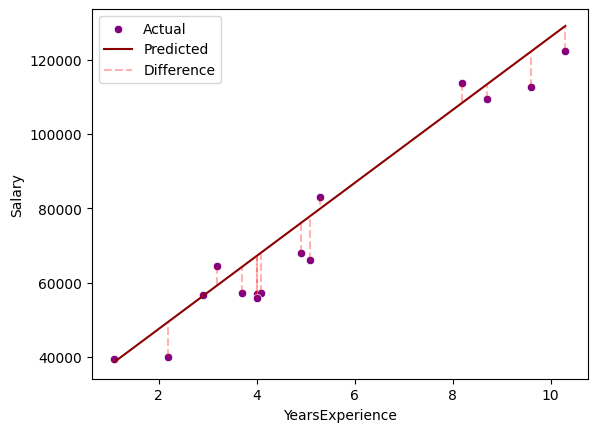

In [29]:
order = np.argsort(x_te['YearsExperience'].values)

sns.scatterplot(
    x=x_te['YearsExperience'].values,
    y=y_te.values,
    label='Actual',
    color='purple'
)

sns.lineplot(
    x=x_te['YearsExperience'].values[order],
    y=y_pred.ravel()[order],
    label='Predicted',
    color='darkred'
)

plt.xlabel('YearsExperience')
plt.ylabel('Salary')

plt.vlines(
    x=x_te['YearsExperience'].values[order],
    ymin=y_te.values[order],
    ymax=y_pred.ravel()[order],
    colors='r',
    linestyles='--',
    label='Difference',
    alpha=0.3
)

plt.legend()
plt.show()

purple dots -actual salary,
darkred line-predicted regression line,
red lines-error(difference between actual and predicted value),
longer lines-higher error,
short lines -good predictions,

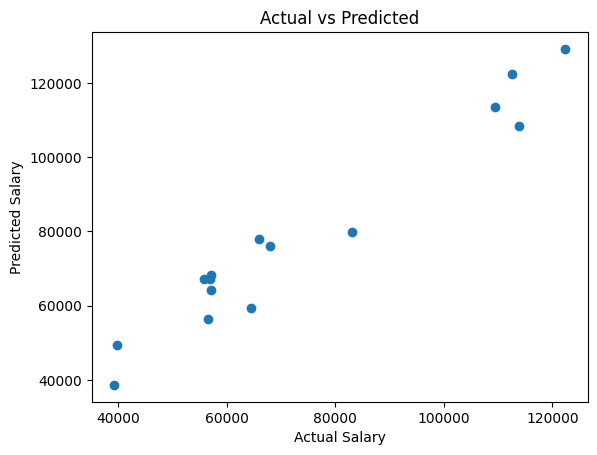

In [37]:
plt.scatter(y_te, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

### 7. Model Evaluation


##### Lower MSE indicates better performance. R² closer to 1 means the model explains most of the variance in salary.
##### Range: 0 to 1 (0=poor,1=perfecr prediction)

In [32]:
MSE = mean_squared_error(y_true=y_te, y_pred=y_pred)
print(f"Mean Square Error: {MSE}")
r2 = r2_score(y_te, y_pred)
print("R2 Score:", r2)

Mean Square Error: 61463554.90419144
R2 Score: 0.914649030895993


### Model Interpretation:
#### Coefficient (slope): This represents how much salary increases for each additional year of experience.
#### Intercept: This is the predicted salary when YearsExperience = 0.

In [34]:
linear_model.coef_

array([26413.3539151])

In [35]:
linear_model.intercept_

np.float64(78494.93333333333)

### Discussion

In this lab, we improved our practical understanding of machine learning by studying the linear regression model. We used a salary dataset that contains two main variables: years of experience and salary. Linear regression was chosen because a positive relationship between these two variables was assumed 7, that is, as years of experience increase, salary is also expected to increase.
We trained a linear regression model to predict salary based on years of experience. The coefficient (slope) of the model represents how much the salary changes for each additional year of experience. In other words, it shows the rate at which salary increases with experience. The intercept represents the predicted salary when the years of experience are zero, indicating the base starting salary in the model.
Then, we used Mean Squared Error (MSE) as the loss function to evaluate the model’s performance. MSE calculates the average of the squared differences between actual and predicted salary values. It helps us understand how close the model’s predictions are to the actual data, with larger errors being penalized more heavily. A lower MSE value indicates better model accuracy and a better fit to the data.
We also used the R² score, which measures how well the model explains the variation in salary. The value of R² ranges from 0 to 1, where 0 indicates poor performance and 1 indicates a perfect fit.


### Conclusion

In conclusion, the objective of this practical was successfully achieved. The linear regression model demonstrates the relationship between years of experience and salary. The results confirm that salary increases with experience as shown by the positive coefficient, while the intercept represents the estimated starting salary when experience is zero. Overall, the model provides a good understanding of how salary can be predicted based on experience.
